In [64]:
import os
import numpy as np
import pandas as pd

import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

# Define node and edge colors

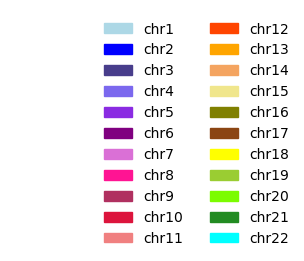

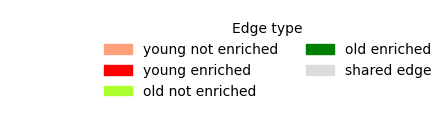

In [13]:
import matplotlib.patches as mpatches

# Create legend for chromosomes
c32_palette = [
    (173, 216, 230),
    (0, 0, 255),
    (72, 61, 139),
    (123, 104, 238),
    (138, 43, 226),
    (128, 0, 128),
    (218, 112, 214),
    (255, 20, 147),
    (176, 48, 96),
    (220, 20, 60),
    (240, 128, 128),
    (255, 69, 0),
    (255, 165, 0),
    (244, 164, 96),
    (240, 230, 140),
    (128, 128, 0),
    (139, 69, 19),
    (255, 255, 0),
    (154, 205, 50),
    (124, 252, 0),
    (34, 139, 34),
    (0, 255, 255),
    (0, 139, 139),
    (128, 128, 128),
]

from colormap import rgb2hex

c32_palette = [rgb2hex(c[0], c[1], c[2]) for c in c32_palette]


colors = list(c32_palette)
node_color_dict = {
    f"chr{chrom}": colors[chrom - 1] for chrom in np.arange(1, 22 + 1, 1)
}
legend_patches = [
    mpatches.Patch(color=color, label=label) for label, color in node_color_dict.items()
]

fig, ax = plt.subplots(figsize=(1, 1))
ax.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=2,
    frameon=False,
)
ax.axis("off")

# plt.savefig(f"{FIGURE_DIR}main/fig3/chrom_legend.svg", bbox_inches = 'tight')
plt.show()

# Create legend for edges
edge_color_dict = {
    "young not enriched": "lightsalmon",
    "young enriched": "red",
    "old not enriched": "greenyellow",
    "old enriched": "green",
    "shared edge": "gainsboro",
}
legend_patches = [
    mpatches.Patch(color=color, label=label) for label, color in edge_color_dict.items()
]

fig, ax = plt.subplots(figsize=(1, 1))
ax.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=2,
    frameon=False,
    title="Edge type",
)
ax.axis("off")
# plt.savefig(f"{FIGURE_DIR}main/fig3/edge_type_legend.svg", bbox_inches = 'tight')

plt.show()

# Load metadata (genesets, enriched edges, etc)

## Enriched edges

In [40]:
observed_edge_enrichment_results = pd.read_hdf(
    '../data/young_old/observed_edge_enrichment_results_lifted.h5', key=None, mode="r", errors="strict"
)

# Enriched edges
alpha = 0.1

enriched_edges_list = observed_edge_enrichment_results[
    (observed_edge_enrichment_results["age"].isin(["young", "old"]))
    & (observed_edge_enrichment_results["ncrna_pval"] <= alpha)
]["edge_id"].values
print(f"Number of age-pure and ncRNA-enriched edges = {len(enriched_edges_list)}")
print(
    f"Percentage of total = {len(enriched_edges_list)/len(observed_edge_enrichment_results)*100}"
)

enriched_edges = [tuple(e.split("-")) for e in enriched_edges_list]

Number of age-pure and ncRNA-enriched edges = 16185
Percentage of total = 1.0390585878818228


## Aging genesets

In [33]:
# Load adhesome.org data
components_df = pd.read_csv( "../data/genesets/adhesome/components.csv", header=0, index_col=None)
adhesome_df = components_df[
    ["Official Symbol", "Protein name", "Functional Category", "FA"]
]
adhesome_df.columns = ["hgnc_id", "protein", "functional_category", "FA"]

import json

# Function to load gene sets
def load_geneset_from_json(file, entry="geneSymbols"):
    data = json.load(open(file))
    genes = data[list(data.keys())[0]][entry]
    return genes

In [34]:
dir_ref = '../data/genesets/custom_aging/'
# Load gene sets
geneset_files = [
    dir_ref + "SAUL_SEN_MAYO.v2023.2.Hs.json",
    dir_ref + "REACTOME_CELLULAR_SENESCENCE.v2023.2.Hs.json",
    dir_ref
    + "REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENOTYPE_SASP.v2023.2.Hs.json",
    dir_ref + "KEGG_TGF_BETA_SIGNALING_PATHWAY.v2023.2.Hs.json",
    dir_ref + "HALLMARK_TGF_BETA_SIGNALING.v2023.2.Hs.json",
    dir_ref + "REACTOME_TGF_BETA.json",
    dir_ref + "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION.v2023.2.Hs.json",
    dir_ref + "HALLMARK_TNFA_SIGNALING_VIA_NFKB.v2023.2.Hs.json",
    dir_ref + "REACTOME_TNF_SIGNALING.v2023.2.Hs.json",
]
aging_genesets = {}
for file in geneset_files:
    gs = os.path.split(file)[1]
    gs = gs[: gs.index(".")]
    aging_genesets[gs] = load_geneset_from_json(file)
aging_genesets["ADHESOME"] = adhesome_df["hgnc_id"].unique().tolist()

## Reactome

In [73]:
import gseapy as gp

# Reactome gene sets
reactome_genesets = gp.read_gmt("../data/genesets/reactome/c2.cp.reactome.v2023.2.Hs.symbols.gmt")
short_name_reactome_genesets = {}
for k, v in reactome_genesets.items():
    short_name_reactome_genesets[k[k.index("_") + 1 :]] = v

## Enriched ncRNAs

In [56]:
# Load ncRNAs of interest
with open("../data/young_old/ncrna_set_dict.json") as f:
    ncrna_set_dict = json.load(f)
    f.close()

# DE ncRNAs
young_up = ncrna_set_dict["ncrnas_de_up_in_young"]
old_up = ncrna_set_dict["ncrnas_de_up_in_old"]

## Protein coding genes

In [22]:
# Load Ensembl gene locations
ensembl_loc_df = pd.read_csv("../data/genome_data/hg38/chrom_hg38.loc", sep="\t", header=0)
ensembl_loc_df = ensembl_loc_df[["geneName", "#chrom", "chromStart", "chromEnd"]]
ensembl_loc_df = ensembl_loc_df.groupby(["geneName", "#chrom"]).agg(
    {"chromStart": min, "chromEnd": max}
)
ensembl_loc_df = ensembl_loc_df.reset_index()
ensembl_loc_df.columns = ["hgnc_id", "chrom", "chromStart", "chromEnd"]
ensembl_loc_df = ensembl_loc_df.drop_duplicates(subset="hgnc_id")
ensembl_loc_df = ensembl_loc_df.set_index("hgnc_id")
ensembl_loc_df = ensembl_loc_df[
    ensembl_loc_df["chrom"].isin([f"chr{i}" for i in np.arange(1, 22 + 1, 1)])
]

# Load ensembl-HGNC mapping
ensembl_hgnc_df = pd.read_csv("../data/genome_data/hgnc2ensembl.csv", sep="\t", header=0)
ensembl_hgnc_df = ensembl_hgnc_df[
    ["Ensembl ID(supplied by Ensembl)", "Approved symbol"]
]
ensembl_hgnc_df.columns = ["ensembl_id", "hgnc_id"]
ensembl_hgnc_df = ensembl_hgnc_df.dropna()
ensembl_hgnc_df = ensembl_hgnc_df.drop_duplicates("hgnc_id")
ensembl_hgnc_df = ensembl_hgnc_df.drop_duplicates("ensembl_id")
ensembl_hgnc_df = ensembl_hgnc_df.set_index("hgnc_id")

# Creat HGNC gene locations
loc_df = pd.concat([ensembl_loc_df, ensembl_hgnc_df], join="inner", axis=1)
loc_df = loc_df.reset_index(drop=False)
loc_df = loc_df[["hgnc_id", "ensembl_id", "chrom", "chromStart", "chromEnd"]]
loc_df = loc_df.set_index("hgnc_id")
loc_df.head()

# Create dictionary mapping Ensembl ID to HGNC ID
ensembl2hgnc = {loc_df.loc[idx, "ensembl_id"]: idx for idx in loc_df.index}
hgnc2ensembl = {idx: loc_df.loc[idx, "ensembl_id"] for idx in loc_df.index}

/tmp/ipykernel_3460510/3900034305.py:4: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ensembl_loc_df = ensembl_loc_df.groupby(["geneName", "#chrom"]).agg(
/tmp/ipykernel_3460510/3900034305.py:4: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ensembl_loc_df = ensembl_loc_df.groupby(["geneName", "#chrom"]).agg(


In [23]:
# Load Biomart data for protein coding genes
biomart_df = pd.read_csv(
    "../data/genome_data/biomart_data.csv", sep=",", header=0, index_col=0
)
pc_genes = biomart_df[biomart_df["gene_biotype"] == "protein_coding"][
    "ensembl_gene_id"
].unique()
pc_genes_hgnc = [ensembl2hgnc[g] for g in pc_genes if (g in ensembl2hgnc.keys())]
print(f"Number of protein coding genes = {len(pc_genes_hgnc)}")

Number of protein coding genes = 18294


In [25]:
import pybedtools
resol = 250000
# First, we load chromosome sizes obtined from the UCSC genome browser.
chromsize_df = pd.read_csv("../data/genome_data/hg38/chrom_hg38.sizes", sep="\t")
chromsize_df = chromsize_df[["chrom", "size"]]
chromsize_df = chromsize_df[
    chromsize_df["chrom"].isin(["chr" + str(i) for i in np.arange(1, 22 + 1, 1)])
]

# Divide the chromosomes into loci and make bed file.
df_chrom_list = []
for chrom_id in np.arange(1, 22 + 1):
    chrom = f"chr{chrom_id}"
    chrom_size = chromsize_df[chromsize_df["chrom"] == chrom]["size"].values[0]
    stop_pos = np.arange(resol, chrom_size + resol, resol, dtype="int")
    df_chrom = pd.DataFrame()
    df_chrom["chrom"] = [chrom] * len(stop_pos)
    df_chrom["start"] = stop_pos - resol
    df_chrom["stop"] = stop_pos
    df_chrom_list.append(df_chrom)
segment_df = pd.concat(df_chrom_list, axis=0)
bed_segment = pybedtools.BedTool.from_dataframe(segment_df).sort()


# Map genes to their loci
genes_bed = loc_df.reset_index(drop=False)
genes_bed = genes_bed[["chrom", "chromStart", "chromEnd", "hgnc_id"]]
genes_bed.columns = ["chrom", "chromStart", "chromEnd", "name"]
genes_bed = pybedtools.BedTool.from_dataframe(genes_bed).sort()
out = pybedtools.bedtool.BedTool.map(
    bed_segment, genes_bed, c=4, o="distinct", f=1e-9, F=0.1, e=True
)
out_df = out.to_dataframe()
out_df.columns = ["chrom", "start", "end", "genes"]
out_df.loc[:, "genes"] = out_df["genes"].str.split(",")
out_df.loc[:, "genes"] = out_df["genes"].apply(lambda ls: [] if (ls[0] == ".") else ls)

# Create dictionary mapping loci to genes and to protein coding genes
locus2genes = {}
for idx in out_df.index:
    locus = out_df.loc[idx, "chrom"] + "_loc_" + str(out_df.loc[idx, "start"])
    locus2genes[locus] = out_df.loc[idx, "genes"]

locus2pcgenes = {}
for idx in out_df.index:
    locus = out_df.loc[idx, "chrom"] + "_loc_" + str(out_df.loc[idx, "start"])
    locus2pcgenes[locus] = [g for g in out_df.loc[idx, "genes"] if (g in pc_genes_hgnc)]

# Load LAS network

In [7]:
import pickle

# Load network including intraX contiguous edges
fname = (
    f"../data/young_old/unthresholded_intraXaugmented_las_network_lifted.pkl"
)
with open(fname, "rb") as handle:
    G, node_attributes_df, edge_attributes_df = pickle.load(handle)

In [47]:
import itertools

def add_expression_and_coverage_data(graph, locus2genes, rnaseq_df):
    node_most_expr_gene_dict = {}
    node_sum_log_counts_dict = {}
    node_genes_dict = {}

    for node in tqdm(graph.nodes()):
        ttt = node.split("_")
        other_node_name = "_".join([ttt[1], "loc", ttt[2]])
        genes = sorted(
            set(itertools.chain.from_iterable([locus2genes[other_node_name]]))
        )
        node_genes_dict[node] = genes
        tmp = rnaseq_df.loc[rnaseq_df.hgnc_symbol.isin(genes)].sort_values(
            "sum_log_count", ascending=False
        )
        node_sum_log_counts_dict[node] = np.sum(tmp.loc[:, "sum_log_count"])
        if len(tmp) > 0:
            node_most_expr_gene_dict[node] = tmp.iloc[0]["hgnc_symbol"]
        else:
            node_most_expr_gene_dict[node] = " "
    nx.set_node_attributes(graph, node_most_expr_gene_dict, "most_expressed_gene")
    nx.set_node_attributes(graph, node_sum_log_counts_dict, "sum_log_counts")
    nx.set_node_attributes(graph, node_genes_dict, "covered_genes")
    
rnaseq_df = pd.read_csv("../data/young_old/youngold_data.csv", header=0, index_col=0)
rnaseq_df["sum_log_count"] = rnaseq_df.log_count_young + rnaseq_df.log_count_old

In [48]:
add_expression_and_coverage_data(G, locus2genes, rnaseq_df)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 6305/6305 [00:13<00:00, 460.33it/s]


In [75]:
import itertools
all_nodes = sorted(G.nodes())
all_nodes = ["_loc_".join(n.split("_")[1:3]) for n in all_nodes]
all_covered_genes = sorted(
    set(itertools.chain.from_iterable([locus2genes[n] for n in all_nodes]))
)
print("Genes contained in the overall LAS network", len(all_covered_genes))
covered_pc_genes = set(pc_genes_hgnc).intersection(all_covered_genes)
print("Protein coding genes covered in the overall LAS network", len(covered_pc_genes))

Genes contained in the overall LAS network 24078
Protein coding genes covered in the overall LAS network 12902


# Load subnetworks

Code to compute and identify interesting subnetworks can be found in `Figure3-networks.ipynb`. We load the results in directly.

In [2]:
import pickle

with open("../data/figure3/young_clique2_cluster_graphs.pkl", "rb") as f:
    clique2_subclusters_young = pickle.load(f)
    
with open("../data/figure3/old_clique2_cluster_graphs.pkl", "rb") as f:
    clique2_subclusters_old = pickle.load(f)

# Helper functions

### Plot subgraph

In [36]:
def build_subnetwork(
    G,
    ensembl2hgnc,
    locus2genes,
    aging_genesets,
):
    subG = G.copy()

    # Add pathway_label attribute (used for node shape: box vs ellipse)
    gs_attribute_dict = {
        gs: {
            n: ",".join(
                [
                    ensembl2hgnc[g]
                    for g in nx.get_node_attributes(subG, f"genes_{gs}")[n]
                ]
            )
            for n in subG.nodes()
        }
        for gs in aging_genesets.keys()
    }
    nx.set_node_attributes(
        subG,
        {
            n: ",".join(
                np.unique(
                    [
                        gs_attribute_dict[gs][n]
                        for gs in aging_genesets.keys()
                        if len(gs_attribute_dict[gs][n]) > 0
                    ]
                )
            )
            for n in subG.nodes()
        },
        "pathway_label",
    )

    return subG


def create_subnetwork_html(
    subG_selected,
    node_color_dict,
    highlighted_edges=None,
):
    highlighted_edges = set(highlighted_edges) if highlighted_edges else set()

    #####################################################################################
    # Node attributes
    #####################################################################################

    labels = {
        node: node_data["most_expressed_gene"]
        for node, node_data in subG_selected.nodes(data=True)
    }
    node_colors = {
        node: node_color_dict[node_data["chrom"]]
        for node, node_data in subG_selected.nodes(data=True)
    }
    node_shapes = {
        node: "box" if len(node_data["pathway_label"]) > 0 else "ellipse"
        for node, node_data in subG_selected.nodes(data=True)
    }
    node_sizes = {
        node: 1 + int(att["sum_log_counts"]) // 2
        for node, att in subG_selected.nodes(data=True)
    }
    node_label_colors = {
        node: "white"
        if node_data["chrom"] in {"chr2", "chr3", "chr6", "chr9", "chr16", "chr17", "chr21"}
        else "black"
        for node, node_data in subG_selected.nodes(data=True)
    }

    #####################################################################################
    # Edge attributes
    #####################################################################################

    edge_sizes = {
        (u, v): int(att["n_shared_bindingncrna"]) + 1
        for u, v, att in subG_selected.edges(data=True)
    }
    edge_colors = {}
    for u, v, att in subG_selected.edges(data=True):
        is_highlighted = not highlighted_edges or (u, v) in highlighted_edges or (v, u) in highlighted_edges
        if att["age"] == "young":
            edge_colors[(u, v)] = "red" if is_highlighted else "lightsalmon"
        elif att["age"] == "old":
            edge_colors[(u, v)] = "green" if is_highlighted else "greenyellow"
        else:
            edge_colors[(u, v)] = "darkgray" if is_highlighted else "gainsboro"

    #####################################################################################
    # Build Pyvis graph
    #####################################################################################

    pyvis_graph = Network(
        height="1000px", width="1000px", notebook=True, cdn_resources="in_line"
    )
    pyvis_graph.force_atlas_2based()

    for node, node_data in subG_selected.nodes(data=True):
        pyvis_graph.add_node(
            node,
            label=labels[node],
            color=node_colors[node],
            shape=node_shapes[node],
            labelHighlightBold=True,
            title="",
            size=node_sizes[node],
            font={"size": 20, "color": node_label_colors[node]},
        )

    for u, v, att in subG_selected.edges(data=True):
        pyvis_graph.add_edge(
            u,
            v,
            color=edge_colors[(u, v)],
            value=edge_sizes[(u, v)],
            title="",
            label=" ",
            font={"size": 20},
        )

    pyvis_graph.show_buttons(["physics"])
    return pyvis_graph

## Plot ncrna coverage

In [86]:
def profile_ncrna_coverage(
    network, young_up, old_up, ens2hgnc_dict, max_comb=3, get_unique_coverage=False
):
    all_edges = set()
    ncrna_edge_dict = {}

    for u, v, dat in network.edges(data=True):
        edge = "-".join([u, v])
        all_edges.add(edge)
        covering_ncrnas = dat["shared_bindingncrna"]
        for ncrna in covering_ncrnas:
            if ncrna in ncrna_edge_dict:
                ncrna_edge_dict[ncrna].append(edge)
            else:
                ncrna_edge_dict[ncrna] = [edge]

    # Generate all combinations of ncrnas keys of size up to 4
    ncrnas_keys = list(ncrna_edge_dict.keys())
    ncrna_combs = []
    for r in range(1, max_comb + 1):  # Sizes 1 to 4
        ncrna_combs.extend(itertools.combinations(ncrnas_keys, r))

    # Merge the values (edges) for each combination
    unique_merged_edges = []
    for combo in tqdm(ncrna_combs):
        merged_edges = list(
            itertools.chain.from_iterable(ncrna_edge_dict[ncrna] for ncrna in combo)
        )
        unique_merged_edges.append(list(set(merged_edges)))  # Remove duplicates

    result = {
        "c_ncrna_id": [],
        "c_ncrna_symb": [],
        "c_ncrnas": [],
        "n_c_ncrnas": [],
        "edges_covered_by_c_ncrnas": [],
        "n_edges_covered_by_c_ncrnas": [],
        "n_all_edges": [],
        "c_ncrna_age": [],
    }
    for i in range(len(unique_merged_edges)):
        ncrnas = list(ncrna_combs[i])
        if len(ncrnas) > 1:
            ncrna_id = ", ".join(ncrnas)
        else:
            ncrna_id = ncrnas[0]

        if len(ncrnas) > 1:
            ncrna_symb = ", ".join(
                [ens2hgnc_dict[x] if x in ens2hgnc_dict else x for x in ncrnas]
            )
        else:
            if ncrnas[0] in ens2hgnc_dict:
                ncrna_symb = ens2hgnc_dict[ncrnas[0]]
            else:
                ncrna_symb = ncrnas[0]
        edges_covered = unique_merged_edges[i]
        n_edges_covered = len(edges_covered)

        if len(set(ncrnas) - young_up) == 0:
            age = "young"
        elif len(set(ncrnas) - old_up) == 0:
            age = "old"
        else:
            age = "shared"

        result["c_ncrna_id"].append(ncrna_id)
        result["c_ncrna_symb"].append(ncrna_symb)
        result["c_ncrnas"].append(ncrnas)
        result["n_c_ncrnas"].append(len(ncrnas))
        result["edges_covered_by_c_ncrnas"].append(edges_covered)
        result["n_edges_covered_by_c_ncrnas"].append(n_edges_covered)
        result["n_all_edges"] = len(all_edges)
        result["c_ncrna_age"].append(age)
    result = pd.DataFrame(result)
    result["prop_edges_covered_by_c_ncrnas"] = (
        result.n_edges_covered_by_c_ncrnas / result.n_all_edges
    )

    if get_unique_coverage:
        edges_uniquely_covered = []
        n_edges_uniquely_covered = []
        for c_ncrna_id in tqdm(result.c_ncrna_id.unique()):
            entry = result.loc[result.c_ncrna_id == c_ncrna_id]
            other_entry = result.loc[result.c_ncrna_id != c_ncrna_id]
            other_edges_covered = set(
                list(
                    itertools.chain.from_iterable(
                        list(other_entry.loc[:, "edges_covered_by_c_ncrnas"])
                    )
                )
            )
            edges_uniquely_covered.append(
                list(
                    set(list(entry["edges_covered_by_c_ncrnas"])[0])
                    - other_edges_covered
                )
            )
            n_edges_uniquely_covered.append(len(edges_uniquely_covered[-1]))
        result["edges_uniquely_covered"] = np.array(edges_uniquely_covered)
        result["n_edges_uniquely_covered"] = np.array(n_edges_uniquely_covered)
        result["prop_edges_uniquely_covered"] = (
            result.n_edges_uniquely_covered / result.n_all_edges
        )
    return result

import textwrap
def plot_ncrna_edge_coverage(ncrna_profile, age="young", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=[6, 4])

    top_single = (
        ncrna_profile[ncrna_profile.n_c_ncrnas == 1]
        .sort_values("prop_edges_covered_by_c_ncrnas", ascending=False)
        .iloc[:10]
    )
    most_present_ncrna = top_single["c_ncrna_id"].iloc[0]
    most_present_age_ncrnas = top_single[top_single.c_ncrna_age == age]["c_ncrna_id"].iloc[:1].tolist()

    max_cov = (
        ncrna_profile[ncrna_profile.n_c_ncrnas <= 3]
        .loc[lambda df: df["c_ncrnas"].apply(lambda x: len(set(x).intersection(most_present_age_ncrnas)) == 0)]
        .sort_values("prop_edges_covered_by_c_ncrnas", ascending=False)
        .iloc[0]
        .prop_edges_covered_by_c_ncrnas
    )

    max_width = 30
    sns.barplot(
        data=top_single,
        y="c_ncrna_symb",
        x="prop_edges_covered_by_c_ncrnas",
        hue="c_ncrna_age",
        palette={"young": "tab:red", "old": "tab:green", "shared": "tab:orange"},
        dodge=False,
        ax=ax,
    )
    ax.set_yticklabels(
        textwrap.fill(x.get_text(), max_width, break_long_words=False)
        for x in ax.get_yticklabels()
    )
    ax.axvline(x=max_cov, c="k", linestyle="--", label="Max. coverage by \nother 3 ncRNAs")
    ax.legend(
        loc="lower right",
        title="ncRNA type",
        fontsize=14,
        title_fontsize=14,
        frameon=True,
        facecolor="white",
        edgecolor="black",
        framealpha=1.0,
    )
    ax.set_xlabel("Proportion of edges covered by the ncRNAs", fontsize=16)
    ax.set_ylabel("")
    ax.set_title("Edge coverage of extended graph by one ncRNA", fontsize=16)
    ax.set_xlim([0, 1])
    ax.tick_params(axis="both", labelsize=14)
    return ax, most_present_ncrna

## Plot top GO pathways

In [80]:
import gseapy as gp

def perform_go_analysis(foreground_genes, background_genes, gene_sets, cutoff):
    # Run GO analysis using gseapy
    result = gp.enrichr(
        gene_list=foreground_genes,
        background=background_genes,
        gene_sets=gene_sets,
        outdir=None,  # You can specify an output directory if needed
        cutoff=cutoff,  # Adjust the cutoff as needed
    )
    # Return the enrichment results DataFrame
    out = result.res2d[result.res2d["Adjusted P-value"] < cutoff]
    return out

def plot_go_for_subcluster(
    sc_gex_data,
    geneset_dict,
    universe,
    color,
    size=10,
    figsize=[6, 4],
    max_term_len=42,
    cluster_names=None,
    ax=None,
):
    res = perform_go_analysis(
        foreground_genes=list(
            set(
                sc_gex_data.loc[
                    sc_gex_data.gene_biotype == "protein_coding", "hgnc_symbol"
                ].unique()
            ).intersection(covered_pc_genes)
        ),
        background_genes=covered_pc_genes,
        gene_sets=geneset_dict,
        cutoff=1,
    )
    res = res.sort_values("Adjusted P-value")
    res["-log10_padj"] = -1 * np.log10(res["Adjusted P-value"])
    res["Term"] = res["Term"].str.replace("_", " ", regex=False)
    res["Term"] = res["Term"].apply(
        lambda x: x[:max_term_len] + "..." if len(x) > max_term_len else x
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    sns.barplot(
        data=res.iloc[:size],
        x="-log10_padj",
        y="Term",
        palette=[color],
        ax=ax,
    )
    ax.set_xlabel("$-\log_{10}(FDR)$", fontsize=16)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=12)
    ax.axvline(x=-np.log10(0.05), linestyle="--", c="k")
    return fig, ax

def get_all_genes_for_graph(graph, gex_data):
    """
    Map genomic graph nodes (loci) to genes and annotate them with expression data.

    This function:
    - Extracts genomic loci from graph nodes
    - Maps each locus to overlapping genes using a lookup table
    - Expands locus-level graph structure into a gene-level table
    - Merges gene expression and annotation metadata
    - Computes total expression across conditions

    Returns:
        DataFrame with:
            - graph node (locus)
            - gene mapping
            - expression values (young/old)
            - gene annotations (biotype, TF status, coordinates)
            - combined read counts
    """
    all_nodes = sorted(graph.nodes())
    all_nodes = ["_loc_".join(n.split("_")[1:3]) for n in all_nodes]

    result = {"node": [], "chrom": [], "gene": []}

    for node in all_nodes:
        all_covered_genes = locus2genes[node]

        for gene in all_covered_genes:
            result["node"].append(node)
            result["chrom"].append(node.split("_")[0])
            result["gene"].append(gene)

    result = pd.DataFrame(result)

    result = pd.merge(
        result,
        gex_data.loc[
            :,
            [
                "hgnc_symbol",
                "reads_young",
                "reads_old",
                "log_count_young",
                "log_count_old",
                "gene_biotype",
                "is_TF",
                "tss",
                "tes",
            ],
        ],
        right_on="hgnc_symbol",
        left_on="gene",
    )

    result["read_sum"] = result["reads_young"] + result["reads_old"]

    return result

# Young networks

## Fig 4a-c

100%|██████████████████████████████████████████████████████████████████████████████████| 156947/156947 [00:00<00:00, 905747.13it/s]
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan

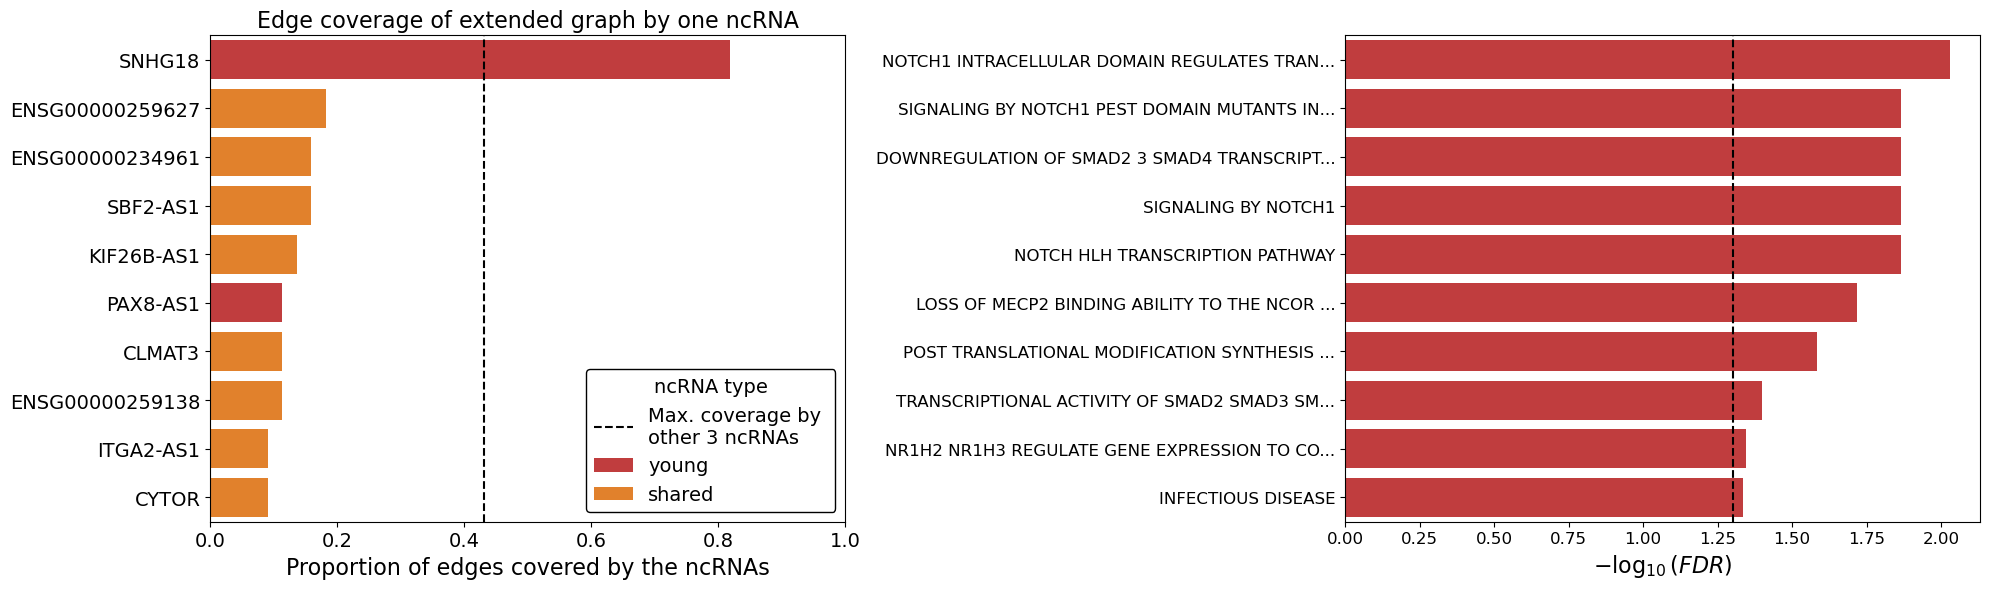

100%|██████████████████████████████████████████████████████████████████████████████████| 117569/117569 [00:00<00:00, 900365.22it/s]
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan

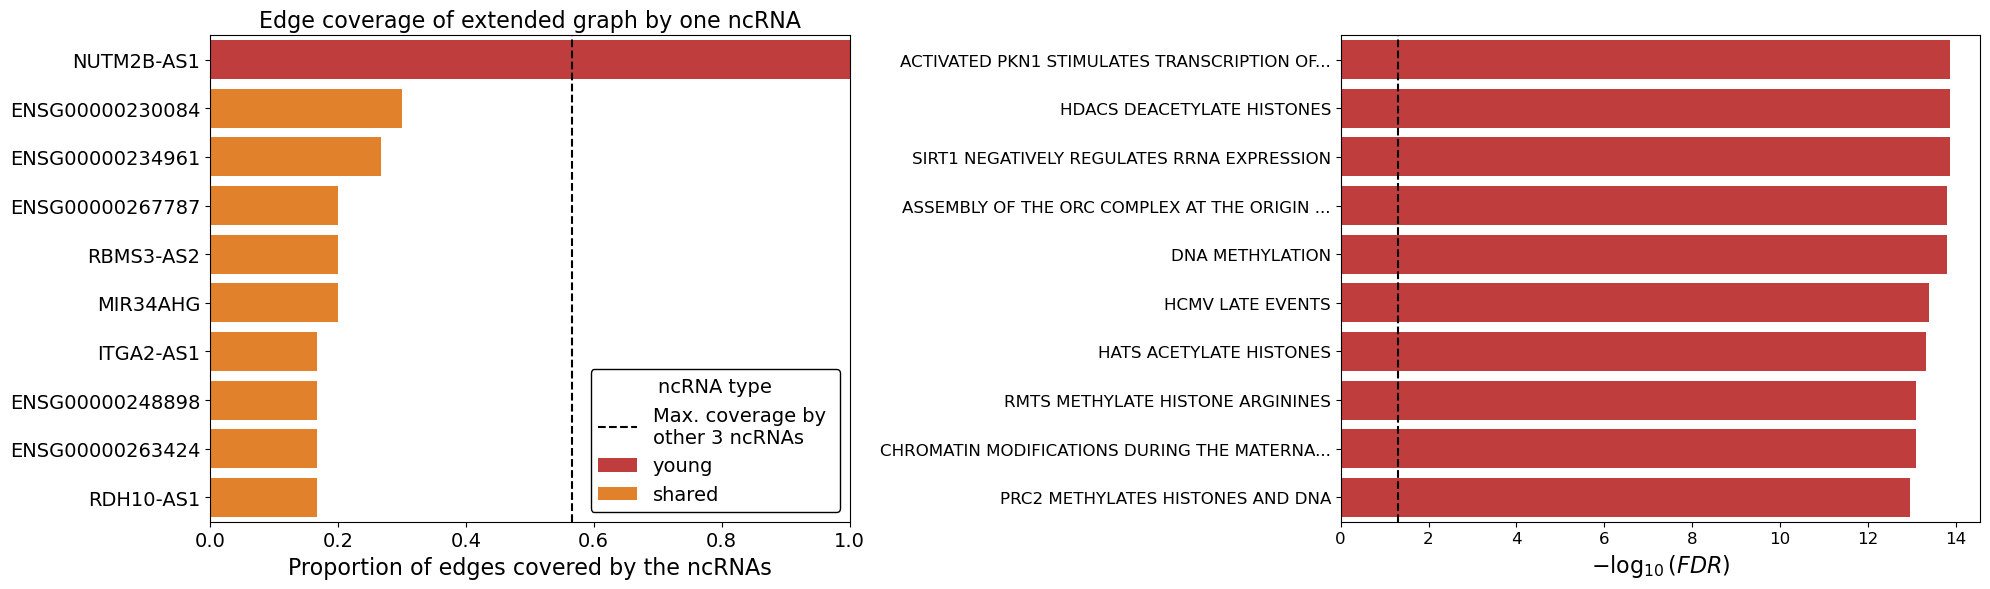

In [88]:
cluster_indices = [65, 96]
for cluster_idx in cluster_indices:
    subgraph = G.subgraph(clique2_subclusters_young[cluster_idx].nodes())

    # Fig 4a
    graph_to_plot = build_subnetwork(subgraph, ensembl2hgnc, locus2genes, aging_genesets)
    create_subnetwork_html(graph_to_plot, node_color_dict, highlighted_edges=enriched_edges).save_graph(
        f"./ext_young_enriched_subcluster{cluster_idx}_graph.html"
    )

    # Fig 4b + 4c
    fig, (ax_b, ax_c) = plt.subplots(1, 2, figsize=[20, 6])

    graph_ncrna_profile = profile_ncrna_coverage(
        subgraph,
        young_up=set(young_up),
        old_up=set(old_up),
        ens2hgnc_dict=ensembl2hgnc,
        max_comb=3,
        get_unique_coverage=False,
    )
    _, most_present_ncrna = plot_ncrna_edge_coverage(graph_ncrna_profile, age = 'young', ax=ax_b)

    gex_data = get_all_genes_for_graph(subgraph, rnaseq_df)
    plot_go_for_subcluster(
        sc_gex_data=gex_data,
        geneset_dict=short_name_reactome_genesets,
        universe=covered_pc_genes,
        color="tab:red",
        max_term_len=42,
        ax=ax_c,
        size=10,
    )

    plt.tight_layout()
    plt.show()

## Fig S14

100%|████████████████████████████████████████████████████████████████████████████████| 1255086/1255086 [00:01<00:00, 645339.95it/s]
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan

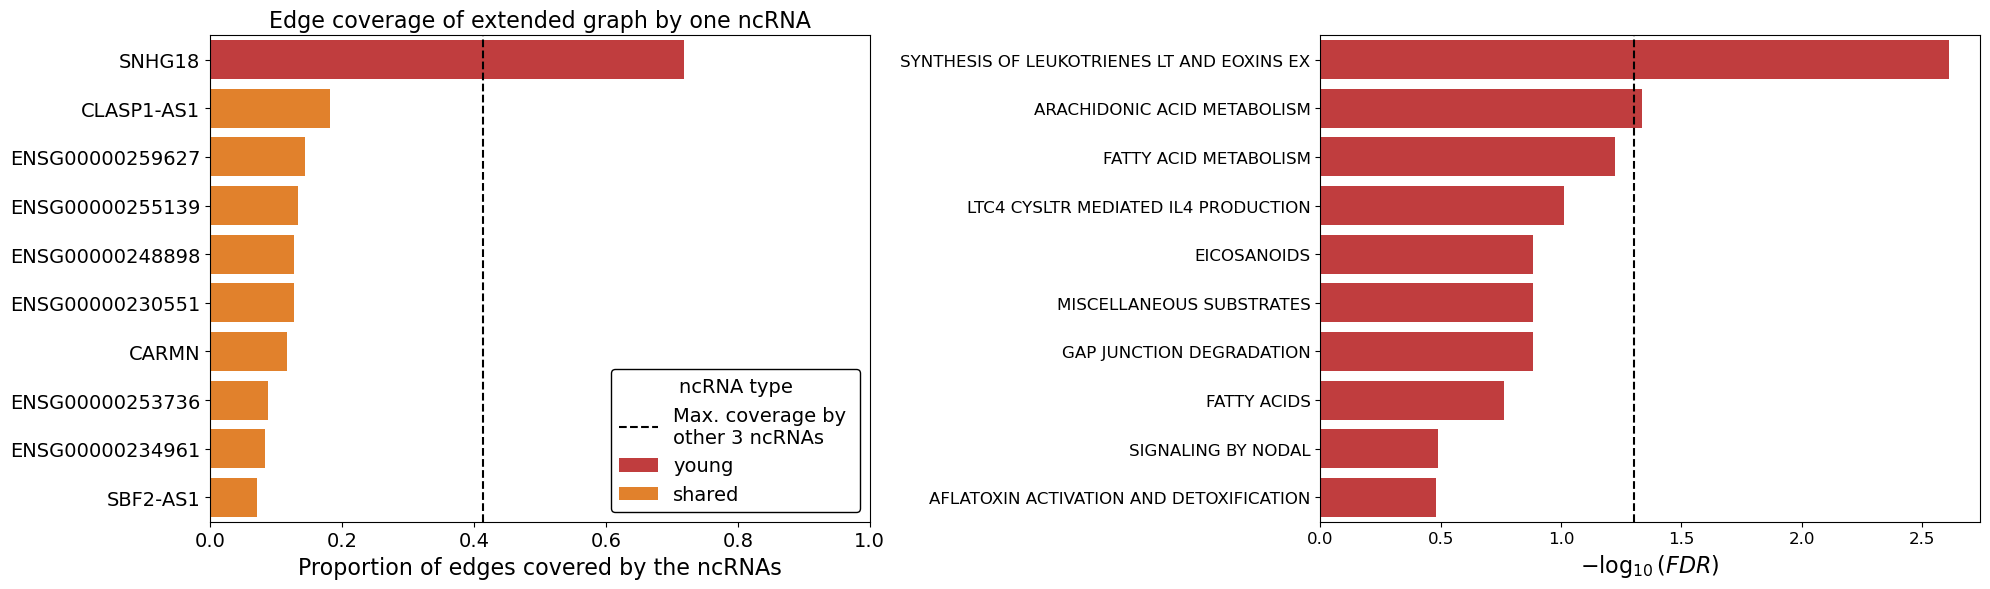

100%|██████████████████████████████████████████████████████████████████████████████████| 620775/620775 [00:00<00:00, 674859.96it/s]
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan

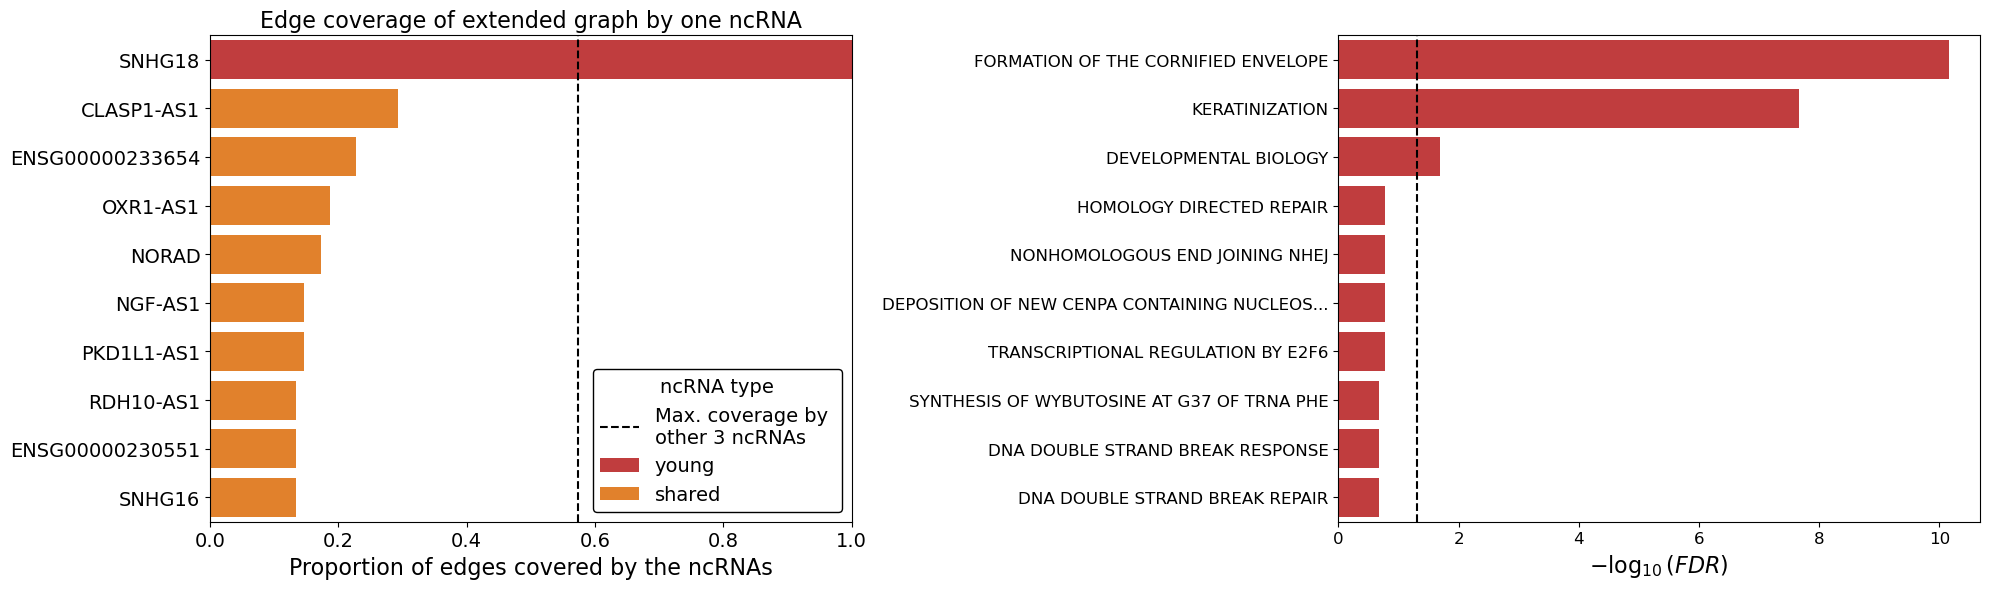

In [91]:
cluster_indices = [14, 21]

for cluster_idx in cluster_indices:
    subgraph = G.subgraph(clique2_subclusters_young[cluster_idx].nodes())

    # Fig 4a
    graph_to_plot = build_subnetwork(subgraph, ensembl2hgnc, locus2genes, aging_genesets)
    create_subnetwork_html(graph_to_plot, node_color_dict, highlighted_edges=enriched_edges).save_graph(
        f"./ext_young_enriched_subcluster{cluster_idx}_graph.html"
    )

    # Fig 4b + 4c
    fig, (ax_b, ax_c) = plt.subplots(1, 2, figsize=[20, 6])

    graph_ncrna_profile = profile_ncrna_coverage(
        subgraph,
        young_up=set(young_up),
        old_up=set(old_up),
        ens2hgnc_dict=ensembl2hgnc,
        max_comb=3,
        get_unique_coverage=False,
    )
    _, most_present_ncrna = plot_ncrna_edge_coverage(graph_ncrna_profile, age = 'young', ax=ax_b)

    gex_data = get_all_genes_for_graph(subgraph, rnaseq_df)
    plot_go_for_subcluster(
        sc_gex_data=gex_data,
        geneset_dict=short_name_reactome_genesets,
        universe=covered_pc_genes,
        color="tab:red",
        max_term_len=42,
        ax=ax_c,
        size=10,
    )

    plt.tight_layout()
    plt.show()

## Old networks

### Fig 4d-f

100%|████████████████████████████████████████████████████████████████████████████████████| 20875/20875 [00:00<00:00, 890884.17it/s]
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan

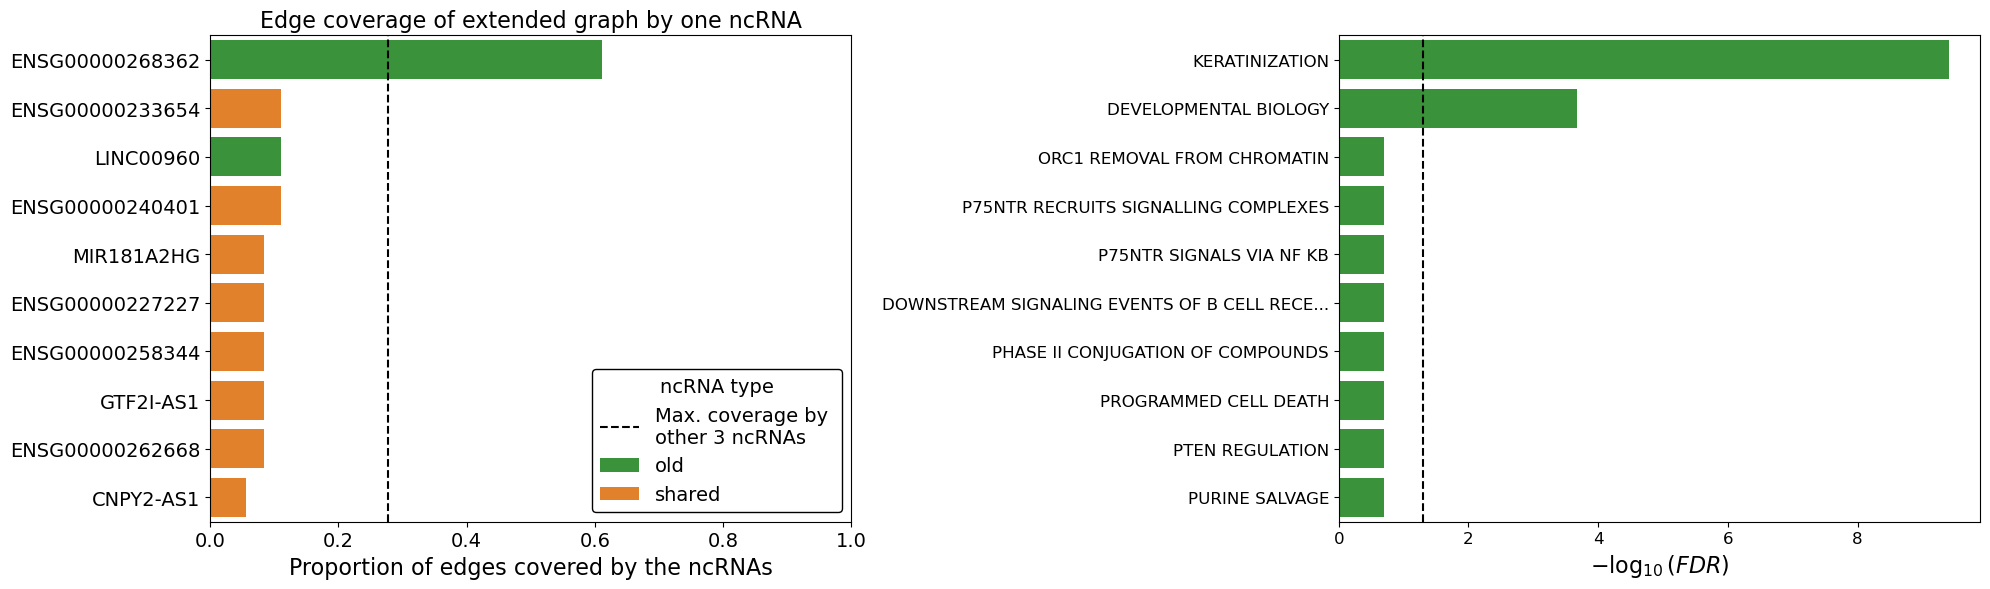

100%|██████████████████████████████████████████████████████████████████████████████████| 295361/295361 [00:00<00:00, 864726.38it/s]
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan

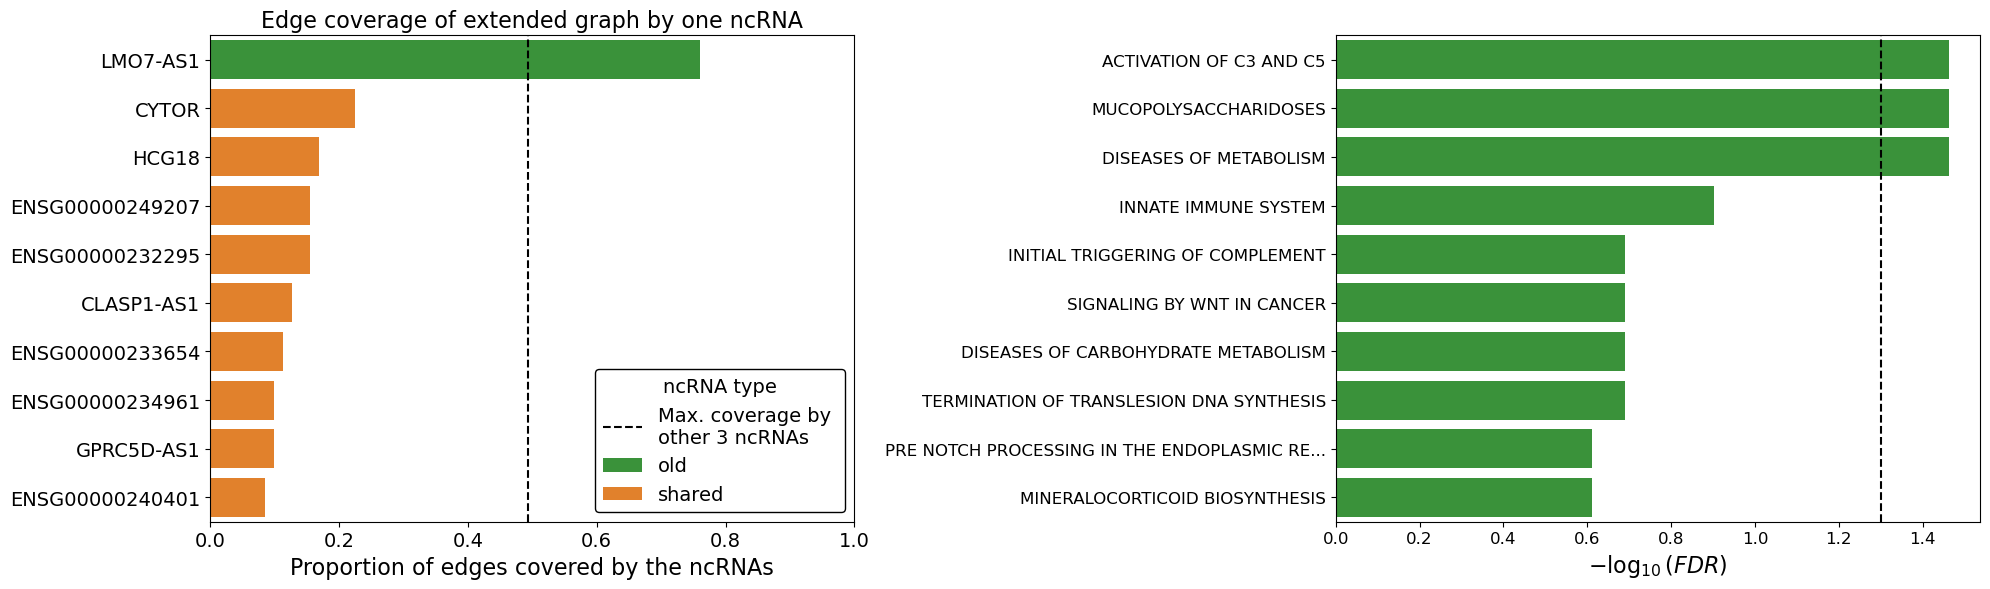

In [94]:
cluster_indices = [76, 79]

for cluster_idx in cluster_indices:
    subgraph = G.subgraph(clique2_subclusters_old[cluster_idx].nodes())

    # Fig 4d
    graph_to_plot = build_subnetwork(subgraph, ensembl2hgnc, locus2genes, aging_genesets)
    create_subnetwork_html(graph_to_plot, node_color_dict, highlighted_edges=enriched_edges).save_graph(
        f"./ext_old_enriched_subcluster{cluster_idx}_graph.html"
    )

    # Fig 4e + 4f
    fig, (ax_b, ax_c) = plt.subplots(1, 2, figsize=[20, 6])

    graph_ncrna_profile = profile_ncrna_coverage(
        subgraph,
        young_up=set(young_up),
        old_up=set(old_up),
        ens2hgnc_dict=ensembl2hgnc,
        max_comb=3,
        get_unique_coverage=False,
    )
    _, most_present_ncrna = plot_ncrna_edge_coverage(graph_ncrna_profile, age = 'old', ax=ax_b)

    gex_data = get_all_genes_for_graph(subgraph, rnaseq_df)
    plot_go_for_subcluster(
        sc_gex_data=gex_data,
        geneset_dict=short_name_reactome_genesets,
        universe=covered_pc_genes,
        color="tab:green",
        max_term_len=42,
        ax=ax_c,
        size=10,
    )

    plt.tight_layout()
    plt.show()